# Dimensionality Reduction and Ordination

After preprocessing and CLR transformation, the dataset remains high-dimensional. To extract meaningful biological signals from sparse, compositional microbiome data, we employ non-linear dimensionality reduction.

### Methodological Rationale

*   **Why we bypass PCA:** Conventional PCA is explicitly discouraged for microbiome data because it assumes linear relationships and emphasizes false correlations. As [Armstrong et al. (2022)](../Papers/PCA_tsne/GeorgeAmstrong2022.pdf), *Discussion* point out, it fails to capture complex, non-linear patterns. While our CLR transformation solves the compositionality issue, forcing the high-dimensional data through a linear PCA risks stripping away critical non-linear signals before they can be visualized [Xu et al., 2020, *Introduction*](../Papers/PCA_tsne/XueliXu2020.pdf).

*   **Direct Non-Linear Embedding (t-SNE & UMAP) with Aitchison Distance**: To perfectly preserve the local structure of our data, we skip the PCA step entirely. Following the methodology of [Xu et al., 2020](../Papers/PCA_tsne/XueliXu2020.pdf), we compute the Aitchison distance (mathematically equivalent to the Euclidean distance on CLR-transformed data) across all features and feed it directly into the t-SNE and UMAP algorithms. Non-linear methods like t-SNE and UMAP are uniquely capable of revealing biological fine-scale clusters hidden from linear methods [Armstrong et al. (2022)](../Papers/PCA_tsne/GeorgeAmstrong2022.pdf). As [Xu et al., 2020](../Papers/PCA_tsne/XueliXu2020.pdf) demonstrated, bypassing linear pre-filters and applying the Aitchison distance directly to both algorithms ensures they accurately handle the compositionality of the data, leading to superior representations.

### From Geography to Global Signatures

Plotting individual countries often creates visual noise. To make the ordination interpretable, we aggregate the samples into broader socio-ecological groupings:
*   **Continents:** To identify large-scale biogeographical patterns.
*   **Lifestyle Clusters (Western vs. Non-Western):** To evaluate how industrialization and diet shape the microbial fingerprint.

### Implementation

1.  Compute the high-dimensional **Aitchison distance** directly from all CLR-transformed features (bypassing PCA).
2.  Execute **t-SNE** on this complete distance matrix to visualize non-linear structures in 2D.
3.  Evaluate the resulting clusters based on Geography and Lifestyle categories.

In [1]:
#IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import umap
from sklearn.manifold import TSNE

In [2]:
# Load the CLR-transformed dataset
file_path = '../data/processed/06_clr_healthy_data.csv'
df = pd.read_csv(file_path)

# Feature selection and label extraction
features = [col for col in df.columns if col.startswith('msp')]
X = df[features]
labels = df['Geography']

In [4]:
# Consolidate results into a single plotting DataFrame
df_plot = pd.DataFrame(X, columns=[f'PC{i+1}' for i in range(X.shape[1])])
df_plot['Geography'] = labels.values

# Step 2: t-SNE (Neighborhood focused)
tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42)
X_tsne = tsne.fit_transform(X)
df_plot['tsne_1'], df_plot['tsne_2'] = X_tsne[:, 0], X_tsne[:, 1]

# Step 3: UMAP (Global & Local structure balanced)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)
df_plot['umap_1'], df_plot['umap_2'] = X_umap[:, 0], X_umap[:, 1] # type: ignore

/Users/dario/ZHAW/4.Semester/PA1_repo/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


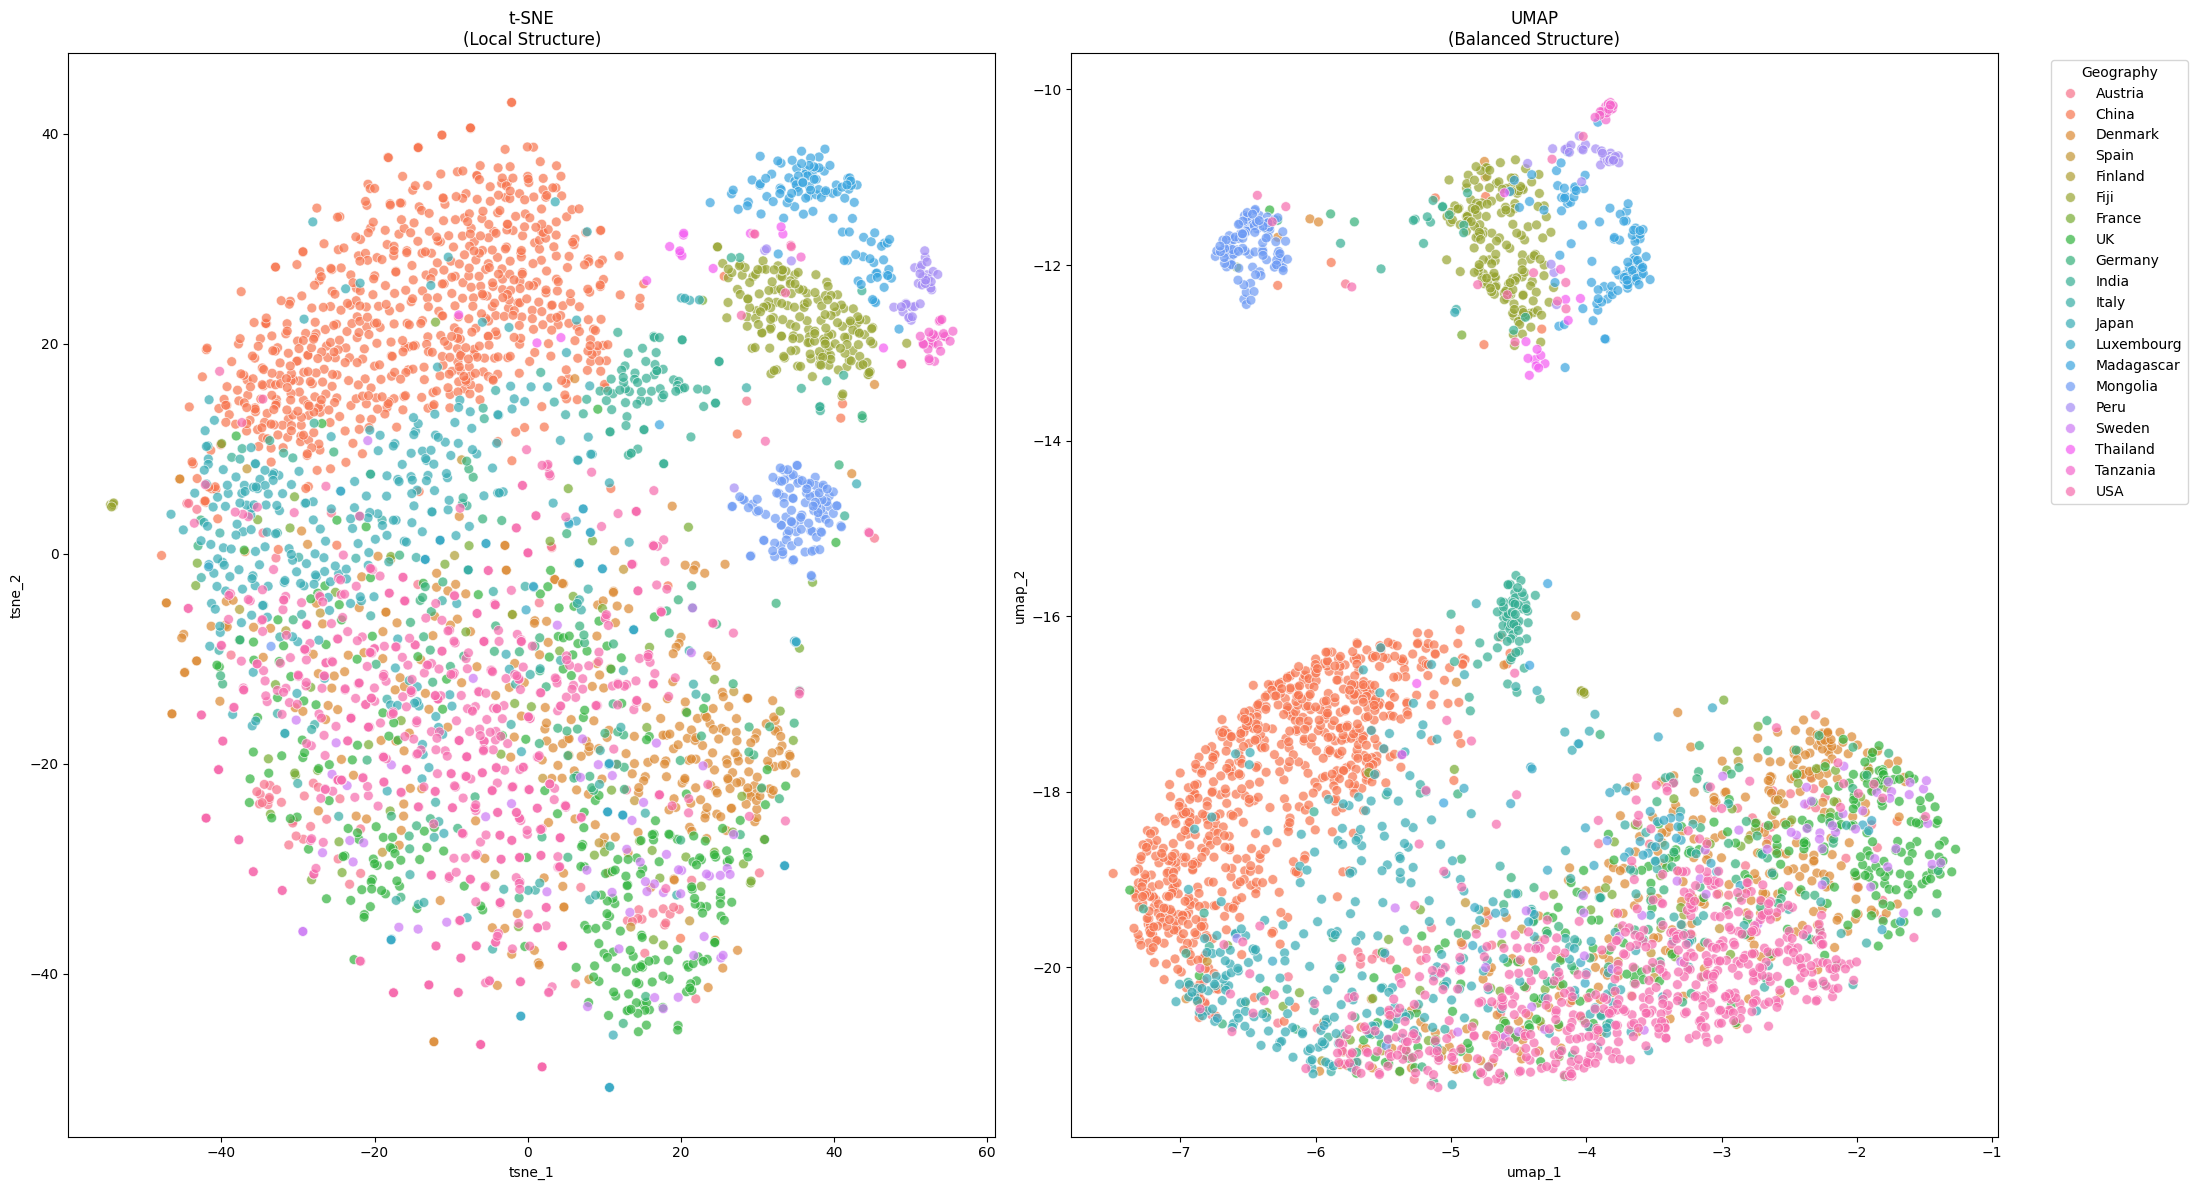

In [17]:
# Visualization: Side-by-side Comparison
fig, axes = plt.subplots(1, 2, figsize=(22, 12))

# Plot t-SNE
sns.scatterplot(data=df_plot, x='tsne_1', y='tsne_2', hue='Geography', ax=axes[0], palette='husl', s=50, alpha=0.7)
axes[0].set_title('t-SNE\n(Local Structure)')
axes[0].get_legend().remove()

# Plot UMAP
sns.scatterplot(data=df_plot, x='umap_1', y='umap_2', hue='Geography', ax=axes[1], palette='husl', s=50, alpha=0.7)
axes[1].set_title('UMAP\n(Balanced Structure)')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Geography')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# 1. Prepare your "t-SNE Features"
# We use the 2D coordinates as our predictors
X_coords = df_plot[['tsne_1', 'tsne_2']] 
y = df_plot['Geography']

# 2. Split the data
# We hide 20% of the data to see if the map generalizes to "unknown" samples
X_train, X_test, y_train, y_test = train_test_split(
    X_coords, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Train the Classifier (as per Xu et al. 2020 recommendation)
# 'rbf' kernel allows for non-linear borders on your 2D map
clf = SVC(kernel='rbf', C=1.0, probability=True)
clf.fit(X_train, y_train)

# 4. Evaluate
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Classification Accuracy based on t-SNE map: {acc:.2%}")
print("\nDetailed Report per Country:")
print(classification_report(y_test, y_pred))

Classification Accuracy based on t-SNE map: 66.77%

Detailed Report per Country:
              precision    recall  f1-score   support

     Austria       0.00      0.00      0.00        12
       China       0.93      0.96      0.94       142
     Denmark       0.62      0.41      0.49        64
        Fiji       0.73      1.00      0.84        37
     Finland       0.00      0.00      0.00         1
      France       0.00      0.00      0.00        12
     Germany       0.00      0.00      0.00        19
       India       0.74      0.74      0.74        19
       Italy       0.00      0.00      0.00        12
       Japan       0.60      0.64      0.62        53
  Luxembourg       0.00      0.00      0.00        10
  Madagascar       1.00      0.82      0.90        22
    Mongolia       0.88      1.00      0.94        22
        Peru       0.56      0.71      0.62         7
       Spain       0.00      0.00      0.00         3
      Sweden       0.00      0.00      0.00        12


/Users/dario/ZHAW/4.Semester/PA1_repo/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/dario/ZHAW/4.Semester/PA1_repo/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/dario/ZHAW/4.Semester/PA1_repo/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

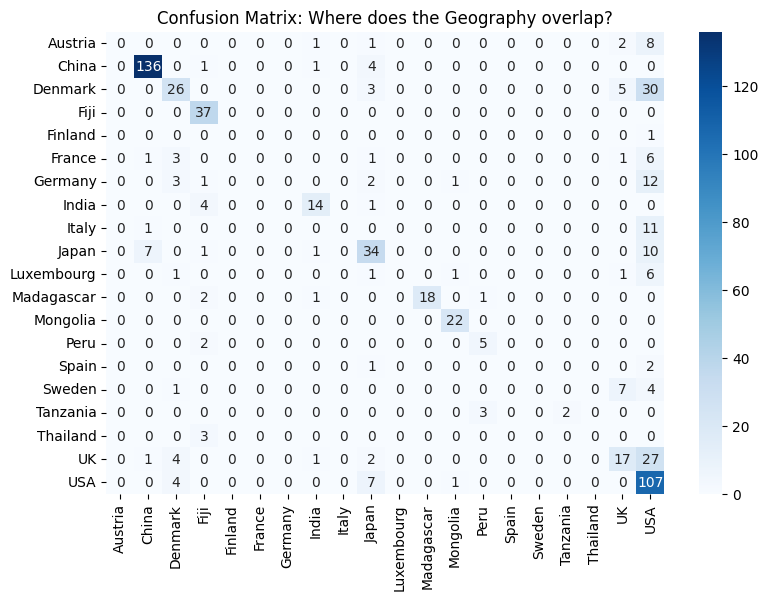

In [15]:
plt.figure(figsize=(9,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=clf.classes_, yticklabels=clf.classes_, cmap='Blues')
plt.title("Confusion Matrix: Where does the Geography overlap?")
plt.show()

/Users/dario/ZHAW/4.Semester/PA1_repo/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


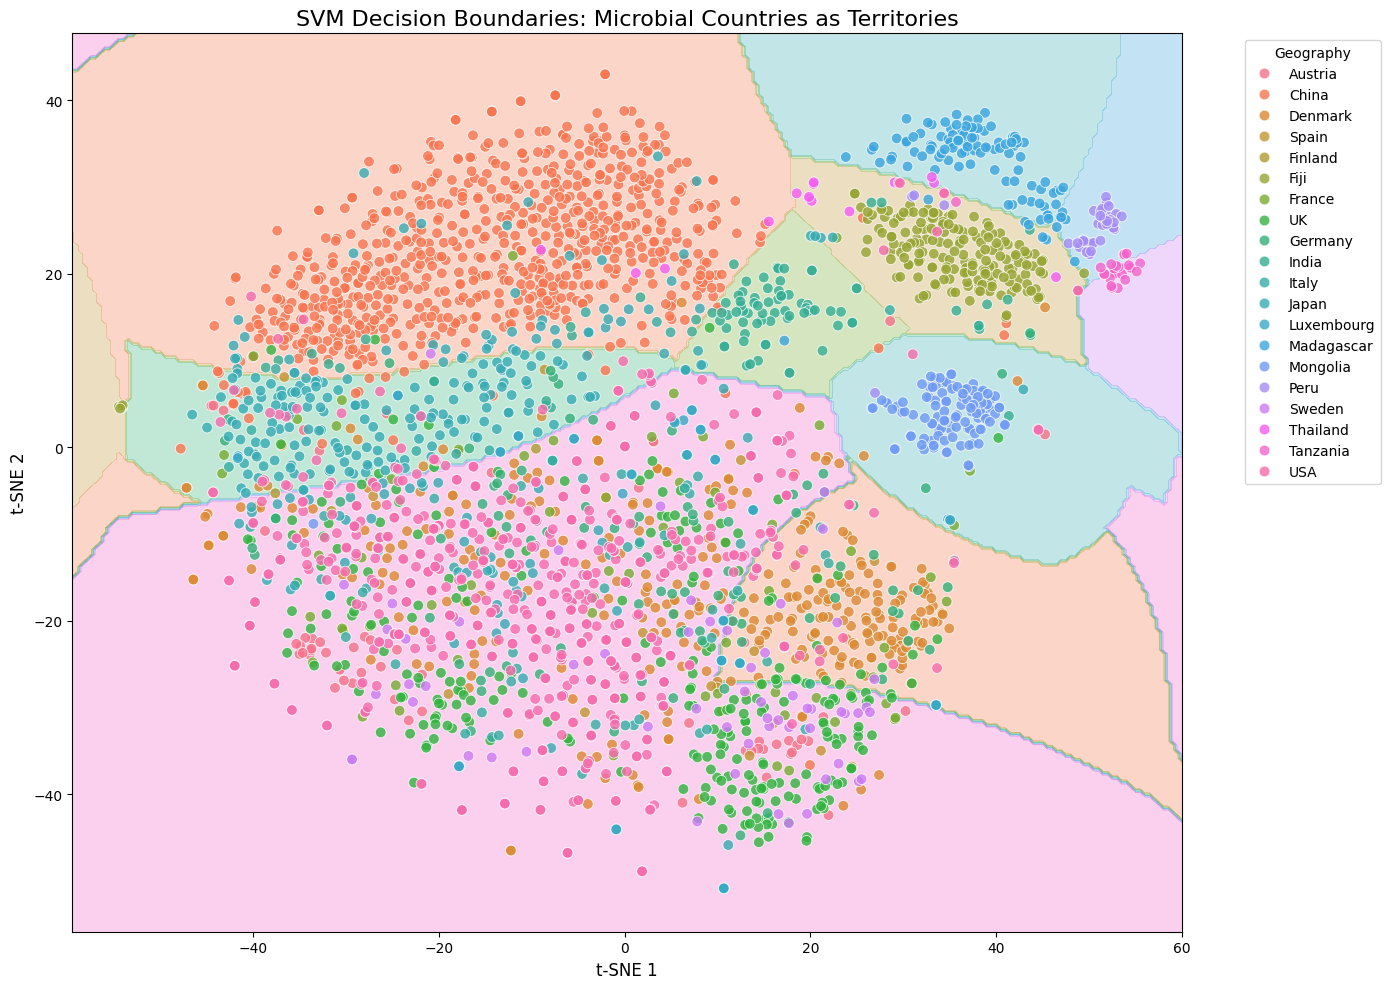

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# 1. Daten vorbereiten (wir nutzen die t-SNE Koordinaten)
X_coords = df_plot[['tsne_1', 'tsne_2']].values
y = df_plot['Geography']

# Wir erstellen ein kategoriales Mapping für die Farben
countries = sorted(df_plot['Geography'].unique())
n_countries = len(countries)
# y_encoded_map = {country: i for i, country in enumerate(countries)}
# y_encoded = df_plot['Geography'].map(y_encoded_map)

# 2. Das feine Raster (Meshgrid) erstellen
# Wir legen ein Gitter über den gesamten Plot, um jeden Punkt zu klassifizieren
x_min, x_max = X_coords[:, 0].min() - 5, X_coords[:, 0].max() + 5
y_min, y_max = X_coords[:, 1].min() - 5, X_coords[:, 1].max() + 5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5), # Auflösung: 0.5
                     np.arange(y_min, y_max, 0.5))

# 3. Das trainierte SVM-Modell (clf) auf dem Raster vorhersagen
# Wir fragen das Modell: "Was ist das für ein Land?" für jeden Gitterpunkt
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

# Da clf.predict() Ländernamen zurückgibt, müssen wir diese wieder in Zahlen codieren
Z_encoded = pd.Series(Z).map({country: i for i, country in enumerate(countries)}).values
Z_encoded = Z_encoded.reshape(xx.shape)

# 4. Den Plot erstellen
plt.figure(figsize=(14, 10))

# Die SVM-Borders als Hintergrund einfärben
custom_cmap_background = ListedColormap(sns.color_palette("husl", n_colors=n_countries).as_hex())
plt.contourf(xx, yy, Z_encoded, cmap=custom_cmap_background, alpha=0.3)

# Die tatsächlichen Datenpunkte darüber legen
scatter = sns.scatterplot(
    data=df_plot, x='tsne_1', y='tsne_2', hue='Geography', 
    palette='husl', s=60, alpha=0.8, edgecolor='w'
)

# Layout und Legende
plt.title("SVM Decision Boundaries: Microbial Countries as Territories", fontsize=16)
plt.xlabel("t-SNE 1", fontsize=12)
plt.ylabel("t-SNE 2", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Geography')

plt.tight_layout()
plt.show()